#### 1. Import Libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

pd.set_option("display.max_columns", None)

#### 2. Load Dataset

In [2]:
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding = "latin1")

print("Initial Dataset Shape:",df.shape)
df.head()

Initial Dataset Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


#### 3. Standardize Column Names

In [3]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)

df.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_email,customer_fname,customer_id,customer_lname,customer_password,customer_segment,customer_state,customer_street,customer_zipcode,department_id,department_name,latitude,longitude,market,order_city,order_country,order_customer_id,order_date_dateorders,order_id,order_item_cardprod_id,order_item_discount,order_item_discount_rate,order_item_id,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,order_region,order_state,order_status,order_zipcode,product_card_id,product_category_id,product_description,product_image,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


#### 4. Dataset Overview & Column Review

In [4]:
df.info()

#Missing Value percentage
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)
missing_percentage[missing_percentage > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   type                         180519 non-null  object 
 1   days_for_shipping_real       180519 non-null  int64  
 2   days_for_shipment_scheduled  180519 non-null  int64  
 3   benefit_per_order            180519 non-null  float64
 4   sales_per_customer           180519 non-null  float64
 5   delivery_status              180519 non-null  object 
 6   late_delivery_risk           180519 non-null  int64  
 7   category_id                  180519 non-null  int64  
 8   category_name                180519 non-null  object 
 9   customer_city                180519 non-null  object 
 10  customer_country             180519 non-null  object 
 11  customer_email               180519 non-null  object 
 12  customer_fname               180519 non-null  object 
 13 

order_zipcode           86.24
product_description    100.00
dtype: float64

#### 5. Identify Key Columns

In [5]:
order_date = "order_date_dateorders"
delivery_date = "shipping_date_dateorders"
ship_duration = "days_for_shipping_real"

#### 6. Convert Date Columns

In [6]:
df[order_date] = pd.to_datetime(df[order_date], errors="coerce")
df[delivery_date] = pd.to_datetime(df[delivery_date], errors="coerce")

#### 7. Remove Rows with Missing Target

In [7]:
initial_rows = len(df)
df = df.dropna(subset=[ship_duration])

print("Removed rows with missing target:", initial_rows - len(df))

Removed rows with missing target: 0


#### 8. Remove Impossible Records(Delivery < Order)

In [8]:
invalid_date_rows = df[df[delivery_date] < df[order_date]]
print("Invalid date records:", len(invalid_date_rows))

df = df[df[delivery_date] >= df[order_date]]

Invalid date records: 0


#### 9. Handle Missing Values

##### a. Numeric Columns

In [11]:
# numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# numeric_cols.remove(ship_duration)

# for col in numeric_cols:
#     if df[col].isnull().sum() > 0:
#         df[col + "_was_missing"] = df[col].isnull().astype(int)
#         df[col].fillna(df[col].median(), inplace=True)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if ship_duration in numeric_cols:
    numeric_cols.remove(ship_duration)

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        if df[col].notnull().sum() > 0:   # column has at least one valid value
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)
        else:
            print(f"Dropping completely empty numeric column: {col}")
            df = df.drop(columns=[col])



Dropping completely empty numeric column: product_description


##### b. Categorical Columns

In [12]:
# categorical_cols = df.select_dtypes(include="object").columns

# for col in categorical_cols:
#     df[col].fillna("Unknown", inplace=True)
categorical_cols = df.select_dtypes(include="object").columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")


#### 10. Remove Duplicate Records

In [13]:
print("Duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows before removal: 0


#### 11. Outlier Detection & Handling (Target Variable)

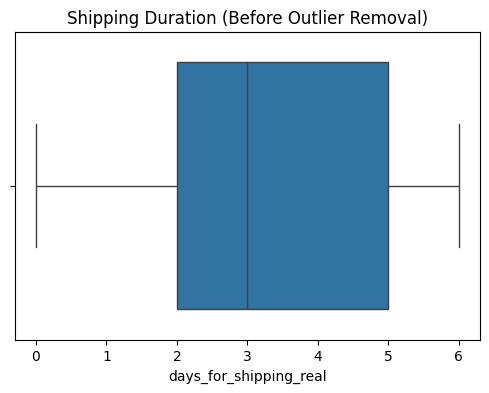

95th Percentile Lead Time: 6.0
Shape after outlier removal: (180519, 52)


In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df[ship_duration])
plt.title("Shipping Duration (Before Outlier Removal)")
plt.show()

p95 = df[ship_duration].quantile(0.95)
print("95th Percentile Lead Time:", p95)

df = df[df[ship_duration] <= p95]

print("Shape after outlier removal:", df.shape)

#### 12. CLeaning Validation(Before Dropping Columns)

In [15]:
assert df[ship_duration].isnull().sum() == 0
assert (df[ship_duration] < 0).sum() == 0
assert (df[delivery_date] < df[order_date]).sum() == 0
assert df.duplicated().sum() == 0

print("✅ Cleaning validation passed")


✅ Cleaning validation passed


#### 13. Remove Data Leakage Columns

In [16]:
leakage_cols = [
    "delivery_status",
    "late_delivery_risk",
    "shipping_date_dateorders",
    "order_status",
]

df = df.drop(columns=[c for c in leakage_cols if c in df.columns])
if "days_for_shipment_scheduled" in df.columns:
    df = df.drop(columns=["days_for_shipment_scheduled"])
print("days_for_shipment_scheduled" in df.columns)



False


#### 14. Remove Privacy Column

In [17]:
privacy_cols = [
    "customer_email",
    "customer_password",
    "customer_fname",
    "customer_lname",
    "product_image",
    "product_description"
    "customer_street"
]

df = df.drop(columns=[c for c in privacy_cols if c in df.columns])


#### 15. Remove HIgh-Cardinaloty IDS

In [18]:
id_cols = [
    "order_id",
    "customer_id",
    "order_customer_id",
    "order_item_id",
    "product_card_id",
    "order_item_cardprod_id",
    "category_id",
    "department_id"
]

df = df.drop(columns=[c for c in id_cols if c in df.columns])

#### 16. Basic Time Feature Engineering

In [19]:
df["order_year"] = df[order_date].dt.year
df["order_month"] = df[order_date].dt.month
df["order_day"] = df[order_date].dt.day
df["order_dayofweek"] = df[order_date].dt.dayofweek
df["is_weekend"] = df["order_dayofweek"].isin([5,6]).astype(int)


#### 17. Create Route Feature

In [20]:
df["route"] = df["order_state"] + "_" + df["customer_state"]

#### 18. Filter Low-Volume Routes

In [21]:
route_counts = df["route"].value_counts()
valid_routes = route_counts[route_counts > 50].index
df = df[df["route"].isin(valid_routes)]

print("Shape after route filtering:", df.shape)

Shape after route filtering: (95597, 40)


#### 19. Final Validation Check

In [22]:
assert df[ship_duration].isnull().sum() == 0
assert (df[ship_duration] < 0).sum() == 0
assert df.duplicated().sum() == 0

print("✅ Final dataset ready for modeling")



✅ Final dataset ready for modeling


#### 20. Save Final Cleaned Dataset

In [23]:
df.to_csv("initial_cleaned_supply_chain_data.csv", index=False)
print("✅ Cleaned dataset saved as final_cleaned_supply_chain_data.csv")


✅ Cleaned dataset saved as final_cleaned_supply_chain_data.csv


### FINAL CLEANING AUDIT & DOCUMENTATION BLOCK

In [24]:
print("ROW REDUCTION SUMMARY")

print(f"Initial rows: {initial_rows}")
print(f"Final rows after cleaning: {len(df)}")
print(f"Total rows removed: {initial_rows - len(df)}")


# TARGET VARIABLE VALIDATION
print("\nTARGET VARIABLE DISTRIBUTION")
ship_duration = "days_for_shipping_real"

print(df[ship_duration].describe())


# If classification target exists, check imbalance
if "late_delivery_risk" in df.columns:
    print("\nClass Distribution:")
    print(df["late_delivery_risk"].value_counts())
    print("\nClass Percentage:")
    print(df["late_delivery_risk"].value_counts(normalize=True) * 100)

# LEAKAGE VERIFICATION
print("\n")
print("LEAKAGE VERIFICATION")

leakage_cols_check = [
    "delivery_status",
    "days_for_shipment_scheduled"
]

existing_leakage = [col for col in leakage_cols_check if col in df.columns]

if len(existing_leakage) == 0:
    print("No leakage columns present.")
else:
    print("Warning: Leakage columns still exist:", existing_leakage)


# CORRELATION AUDIT (>0.85)
print("\n")
print("CORRELATION AUDIT (> 0.85)")

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_cols = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.85)
]

print("Highly correlated columns identified:", high_corr_cols)

# FINAL DATA QUALITY SUMMARY (REGENERATED)
print("\nFINAL DATA QUALITY SUMMARY")

final_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes,
    "missing_%": (df.isnull().sum() / len(df) * 100).round(2)
})

final_summary.to_csv("initial_data_quality_summary.csv", index=False)

print("Final data quality summary regenerated.")

# FINAL DATASET SHAPE
print("FINAL DATASET SHAPE")

print(f"Final Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

print("\nCleaning & validation process completed successfully.")


ROW REDUCTION SUMMARY
Initial rows: 180519
Final rows after cleaning: 95597
Total rows removed: 84922

TARGET VARIABLE DISTRIBUTION
count    95597.000000
mean         3.488980
std          1.622553
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max          6.000000
Name: days_for_shipping_real, dtype: float64


LEAKAGE VERIFICATION
No leakage columns present.


CORRELATION AUDIT (> 0.85)
Highly correlated columns identified: ['longitude', 'sales', 'order_item_total', 'order_profit_per_order', 'product_price']

FINAL DATA QUALITY SUMMARY
Final data quality summary regenerated.
FINAL DATASET SHAPE
Final Dataset contains 95597 rows and 40 columns.

Cleaning & validation process completed successfully.


#### 21. Generate Data Quality Summary

In [25]:
data_quality_summary = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes,
    "missing_percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

data_quality_summary.to_csv("initial_data_quality_summary.csv", index=False)
data_quality_summary


,column,data_type,missing_percentage
type,type,object,0.0
days_for_shipping_real,days_for_shipping_real,int64,0.0
benefit_per_order,benefit_per_order,float64,0.0
sales_per_customer,sales_per_customer,float64,0.0
category_name,category_name,object,0.0
customer_city,customer_city,object,0.0
customer_country,customer_country,object,0.0
customer_segment,customer_segment,object,0.0
customer_state,customer_state,object,0.0
customer_street,customer_street,object,0.0


### Visualization

#### 1. Missing Value Check (After Cleaning)

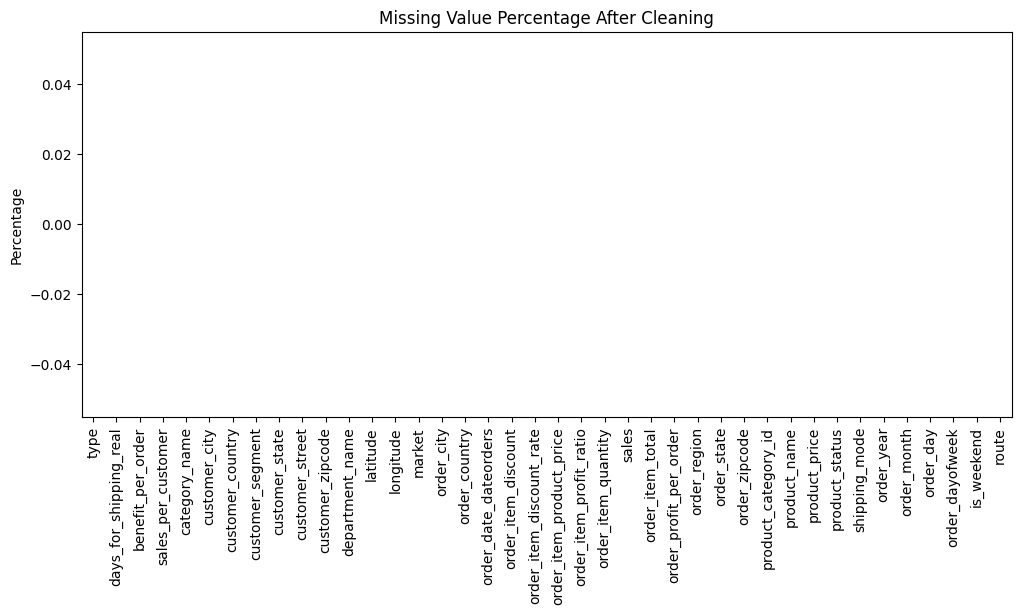

False


In [26]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.title("Missing Value Percentage After Cleaning")
plt.ylabel("Percentage")
plt.show()
print("days_for_shipment_scheduled" in df.columns)


#### 2. Target Distribution

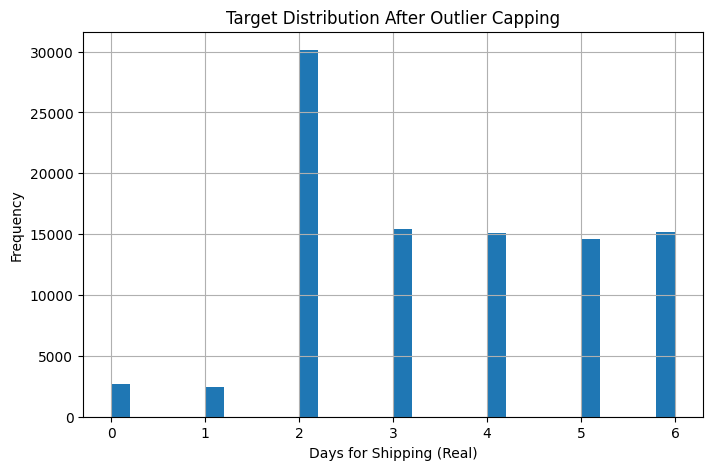

In [27]:
plt.figure(figsize=(8,5))
df["days_for_shipping_real"].hist(bins=30)
plt.title("Target Distribution After Outlier Capping")
plt.xlabel("Days for Shipping (Real)")
plt.ylabel("Frequency")
plt.show()


#### 3. Boxplot for Outlier Check

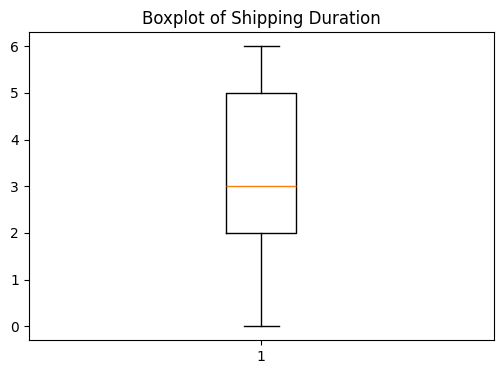

In [28]:
plt.figure(figsize=(6,4))
plt.boxplot(df["days_for_shipping_real"])
plt.title("Boxplot of Shipping Duration")
plt.show()

#### 4. Correlation Heatmap

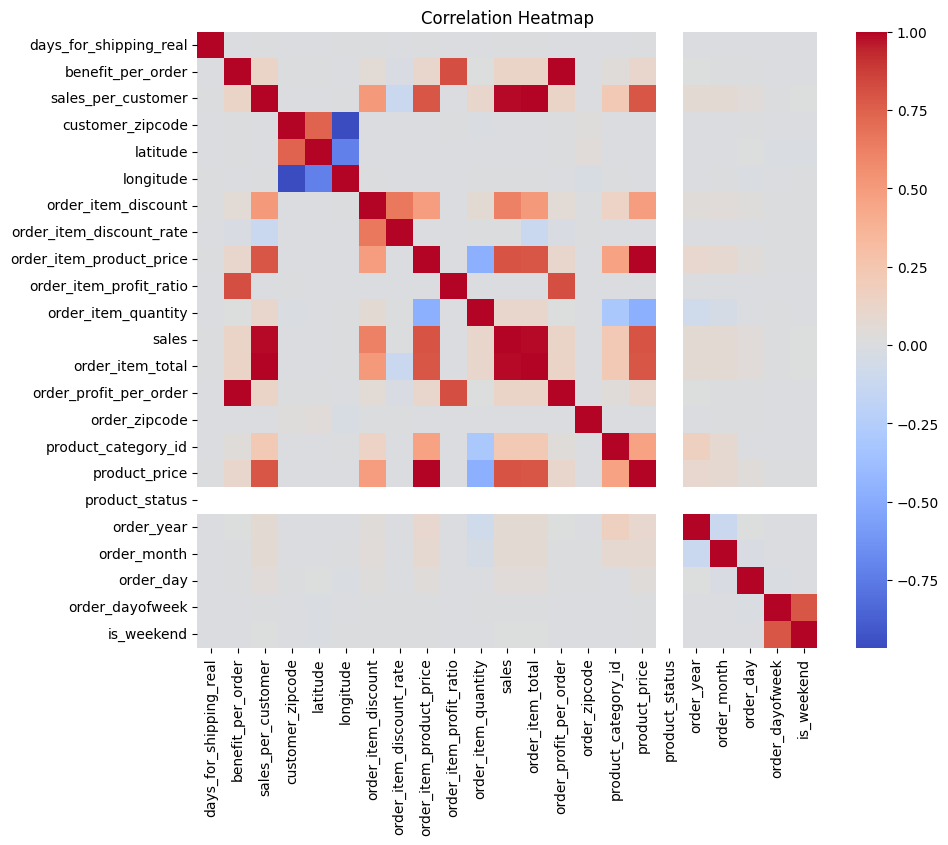

In [29]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


#### 22. Final Shape

In [30]:
print(f"Final Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")



Final Dataset contains 95597 rows and 40 columns.


### Final Extended Version

#### 23. Import

In [31]:
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

#### 24. Load Dataset

In [32]:
df = pd.read_csv("initial_cleaned_supply_chain_data.csv")

ship_duration = "days_for_shipping_real"
order_date_col = "order_date_dateorders"

print("Loaded cleaned dataset:", df.shape)


Loaded cleaned dataset: (95597, 40)


#### 25. DROP product_description

In [33]:
if "product_description" in df.columns:
    df = df.drop(columns=["product_description"])

#### 26. REMOVE LEAKAGE COLUMN

In [34]:
if "days_for_shipment_scheduled" in df.columns:
    df = df.drop(columns=["days_for_shipment_scheduled"])

#### 27. EXTREME OUTLIERS (95th Percentile)

In [35]:
p95 = df[ship_duration].quantile(0.95)

df[ship_duration] = np.where(
    df[ship_duration] > p95,
    p95,
    df[ship_duration]
)

print("Outliers capped at:", p95)

Outliers capped at: 6.0


#### 28. FEATURE ENGINEERING (Order Date Only)

In [36]:
df[order_date_col] = pd.to_datetime(df[order_date_col], errors="coerce")

df["order_day"] = df[order_date_col].dt.day
df["order_month"] = df[order_date_col].dt.month
df["order_weekday"] = df[order_date_col].dt.weekday
df["is_weekend"] = (df["order_weekday"] >= 5).astype(int)

df = df.drop(columns=[order_date_col])

# Remove any date-conversion failures
df = df.dropna()

print("Feature engineering completed.")

Feature engineering completed.


#### 29. REMOVE IDENTIFIERS / HIGH CARDINALITY COLUMNS

In [37]:
remove_cols = [
    "order_id",
    "customer_id",
    "product_id",
    "order_item_id",
    "order_customer_id",
    "order_item_cardprod_id",
    "product_card_id",
    "customer_fname",
    "customer_lname",
    "product_image",
    "product_name"
]

df = df.drop(columns=[c for c in remove_cols if c in df.columns])

print("Identifiers removed.")

Identifiers removed.


#### 30. SEPARATE FEATURES & TARGET

In [38]:
X = df.drop(columns=[ship_duration])
y = df[ship_duration]

#### 31. ENCODE CATEGORICAL VARIABLES

In [39]:
categorical_cols = X.select_dtypes(include="object").columns

low_card_cols = []
high_card_cols = []

for col in categorical_cols:
    if X[col].nunique() <= 15:   # threshold can be 10–20
        low_card_cols.append(col)
    else:
        high_card_cols.append(col)

print("Low-cardinality columns:", low_card_cols)
print("High-cardinality columns dropped:", high_card_cols)

# Drop high-cardinality columns
X = X.drop(columns=high_card_cols)

# Encode only low-card columns
X_encoded = pd.get_dummies(X, columns=low_card_cols, drop_first=True)

print("Shape after controlled encoding:", X_encoded.shape)


Low-cardinality columns: ['type', 'customer_country', 'customer_segment', 'department_name', 'market', 'shipping_mode']
High-cardinality columns dropped: ['category_name', 'customer_city', 'customer_state', 'customer_street', 'order_city', 'order_country', 'order_region', 'order_state', 'route']
Shape after controlled encoding: (95597, 46)


#### 32. TRAIN / VALIDATION / TEST SPLIT

In [40]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y,
    test_size=0.30,
    random_state=42
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (66917, 46)
Validation shape: (14340, 46)
Test shape: (14340, 46)


#### 33. FINAL VALIDATION CHECKS

In [41]:
assert X_train.isnull().sum().sum() == 0
assert X_val.isnull().sum().sum() == 0
assert X_test.isnull().sum().sum() == 0

print("✅ Dataset successfully structured and ready for modeling.")

✅ Dataset successfully structured and ready for modeling.


#### 34. Shape and Size Check

In [42]:
final_df = pd.concat([X_encoded, y], axis=1)

print("Final Shape:", final_df.shape)
print("Memory usage (MB):", final_df.memory_usage(deep=True).sum() / 1024**2)

assert final_df.isnull().sum().sum() == 0
print("No missing values detected.")

Final Shape: (95597, 47)
Memory usage (MB): 18.507311820983887
No missing values detected.


#### 35. Saved Model Ready Dataset

In [43]:
final_df.to_csv("final_cleaned_supply_chain_dataset.csv", index=False)

print("Model-ready dataset saved successfully.")

Model-ready dataset saved successfully.


#### 36. Check Rows and Columns

In [44]:
print(f"Initial rows: {initial_rows}")
print(f"Final rows after cleaning: {len(df)}")
print(f"Total rows removed: {initial_rows - len(df)}")
print(f"Final Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")


Initial rows: 180519
Final rows after cleaning: 95597
Total rows removed: 84922
Final Dataset contains 95597 rows and 39 columns.


### Final Missing Value Percentage Plot

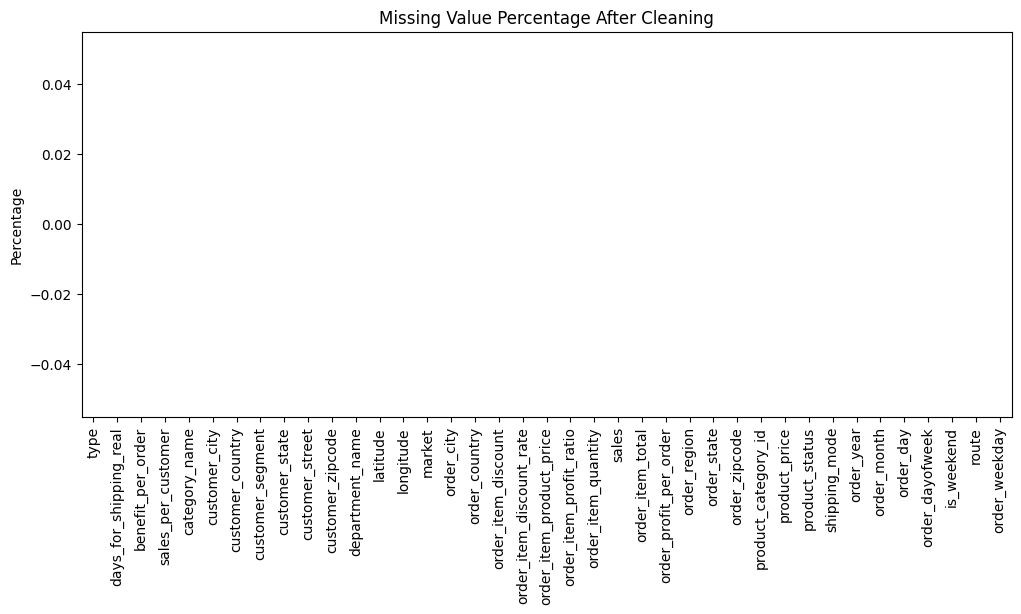

False


In [45]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.title("Missing Value Percentage After Cleaning")
plt.ylabel("Percentage")
plt.show()
print("days_for_shipment_scheduled" in df.columns)

### Final Target Distribution

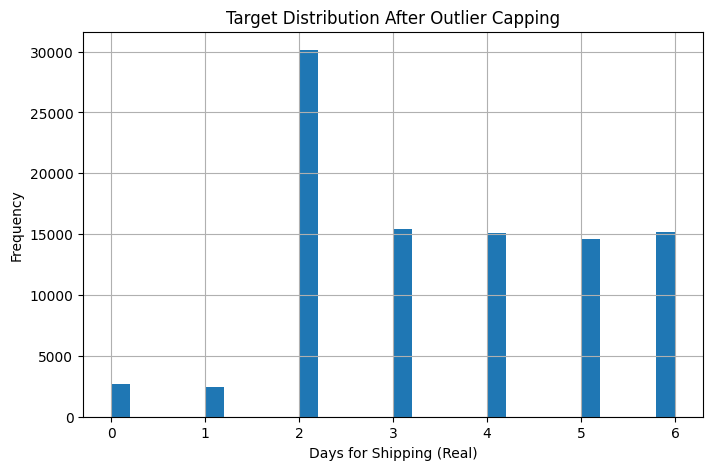

In [46]:
plt.figure(figsize=(8,5))
df["days_for_shipping_real"].hist(bins=30)
plt.title("Target Distribution After Outlier Capping")
plt.xlabel("Days for Shipping (Real)")
plt.ylabel("Frequency")
plt.show()

### Final Boxplot

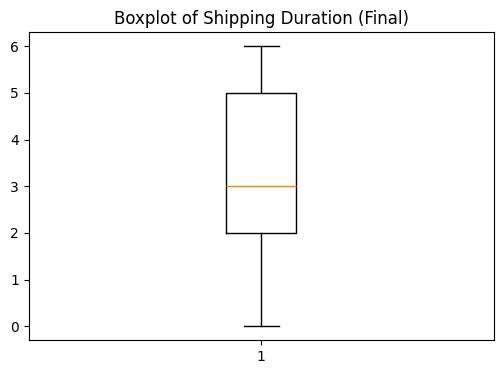

In [47]:
plt.figure(figsize=(6,4))
plt.boxplot(df[ship_duration])
plt.title("Boxplot of Shipping Duration (Final)")
plt.show()

### Final Correlation Heatmap

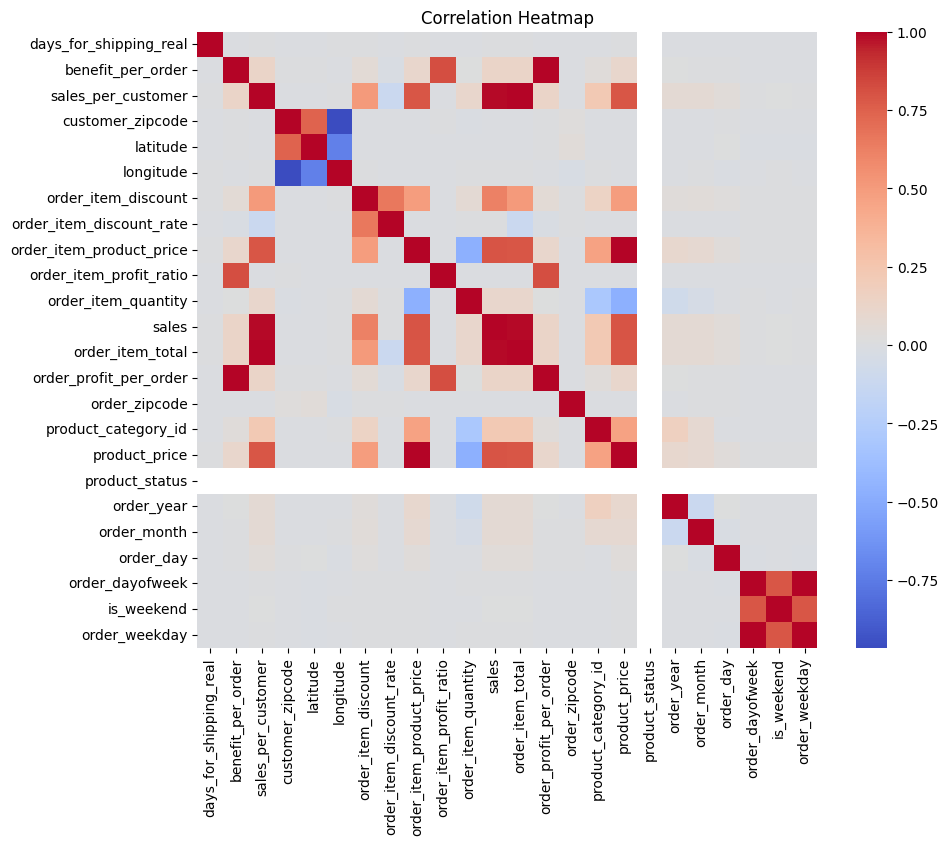

In [48]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

###  FINAL DATA QUALITY SUMMARY

In [49]:
final_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes,
    "missing_%": (df.isnull().sum() / len(df) * 100).round(2)
})

final_summary.to_csv("final_data_quality_summary1.csv", index=False)

print("Final data quality summary regenerated.")

Final data quality summary regenerated.


### Final Test

In [50]:
print(df.shape)
print(df.isnull().sum().sum())
print("days_for_shipment_scheduled" in df.columns)


(95597, 39)
0
False
